# check auroArima results to fix atima orders for all materials

Files found:
  - autoarima_candidates_linear.csv
  - autoarima_candidates_pchip.csv
  - autoarima_candidates_spline.csv

Detailed order comparison:


,material,imputation_method,arima_order,sarima_order,sarima_seasonal_order,arima_aicc,sarima_aicc,delta_aicc,aicc_result,seasonal_result
0,1,linear,"(1, 1, 2)","(1, 1, 2)","(1, 0, 0, 5)",-3842.270,-3844.780,-2.510,SARIMA lower,Seasonal terms selected
1,1,pchip,"(1, 1, 2)","(1, 1, 2)","(1, 0, 0, 5)",-3836.025,-3836.968,-0.943,SARIMA lower,Seasonal terms selected
2,1,spline,"(1, 1, 2)","(1, 1, 2)","(1, 0, 0, 5)",-3857.196,-3858.851,-1.655,SARIMA lower,Seasonal terms selected
3,2,linear,"(1, 1, 1)","(1, 1, 1)","(0, 0, 0, 5)",-4426.001,-4426.001,0.000,Tie,No seasonal terms
4,2,pchip,"(1, 1, 1)","(1, 1, 1)","(0, 0, 0, 5)",-4425.005,-4425.005,0.000,Tie,No seasonal terms
5,2,spline,"(1, 1, 1)","(1, 1, 1)","(0, 0, 0, 5)",-4432.271,-4432.271,0.000,Tie,No seasonal terms
6,3,linear,"(1, 1, 1)","(1, 1, 1)","(0, 0, 2, 5)",-4494.561,-4495.978,-1.417,SARIMA lower,Seasonal terms selected
7,3,pchip,"(1, 1, 1)","(1, 1, 1)","(0, 0, 2, 5)",-4479.282,-4480.862,-1.580,SARIMA lower,Seasonal terms selected
8,3,spline,"(1, 1, 1)","(1, 1, 1)","(0, 0, 2, 5)",-4529.137,-4530.517,-1.380,SARIMA lower,Seasonal terms selected
9,4,linear,"(0, 1, 2)","(0, 1, 2)","(0, 0, 0, 5)",-3772.007,-3772.007,0.000,Tie,No seasonal terms



Summary by interpolation method:


,imputation_method,n_materials,arima_lower_aicc,sarima_lower_aicc,aicc_ties,seasonal_terms_selected,mean_delta_aicc
0,linear,13,2,5,6,5,0.519
1,pchip,13,3,7,3,7,7.404
2,spline,13,2,6,5,7,6.143



Order stability across interpolation methods:


,material,candidate,n_methods,n_unique_specifications,specifications,stable_across_imputation
0,1,arima,3,1,"(1, 1, 2) | (0, 0, 0, 0)",True
1,1,sarima,3,1,"(1, 1, 2) | (1, 0, 0, 5)",True
2,2,arima,3,1,"(1, 1, 1) | (0, 0, 0, 0)",True
3,2,sarima,3,1,"(1, 1, 1) | (0, 0, 0, 5)",True
4,3,arima,3,1,"(1, 1, 1) | (0, 0, 0, 0)",True
5,3,sarima,3,1,"(1, 1, 1) | (0, 0, 2, 5)",True
6,4,arima,3,2,"(0, 1, 1) | (0, 0, 0, 0); (0, 1, 2) | (0, 0, 0...",False
7,4,sarima,3,2,"(0, 1, 1) | (0, 0, 0, 5); (0, 1, 2) | (0, 0, 0...",False
8,5,arima,3,2,"(1, 0, 2) | (0, 0, 0, 0); (2, 0, 2) | (0, 0, 0...",False
9,5,sarima,3,3,"(0, 0, 2) | (1, 0, 0, 5); (1, 0, 0) | (1, 0, 0...",False



Stable model specifications: 34.6%


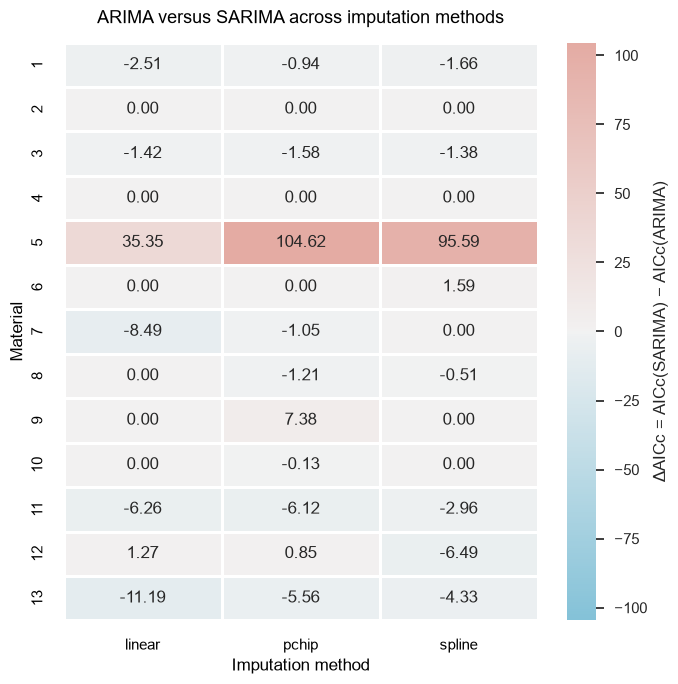

Figure saved to:
D:\TU_DataScience\22_Data Mining Cup\TS-Forecasting-Project\outputs\figures\autoarima_delta_aicc_by_imputation.png


In [6]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


# ============================================================
# 1. Paths
# ============================================================

PROJECT_ROOT = Path.cwd()

# If the notebook is inside notebooks/
if not (PROJECT_ROOT / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULT_DIR = PROJECT_ROOT / "outputs" / "autoarima"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

result_files = sorted(
    RESULT_DIR.glob("autoarima_candidates_*.csv")
)

if not result_files:
    raise FileNotFoundError(
        f"No AutoARIMA result files found in:\n{RESULT_DIR}"
    )

print("Files found:")
for file in result_files:
    print(f"  - {file.name}")


# ============================================================
# 2. Read and combine result files
# ============================================================

frames = []

for file in result_files:
    df_file = pd.read_csv(file)

    # Fallback if an older CSV does not contain this column.
    if "imputation_method" not in df_file.columns:
        method = file.stem.replace(
            "autoarima_candidates_",
            "",
        )
        df_file["imputation_method"] = method

    df_file["source_file"] = file.name
    frames.append(df_file)

results_raw = pd.concat(
    frames,
    ignore_index=True,
)

results = results_raw[
    results_raw["status"].eq("success")
].copy()

results["material"] = (
    pd.to_numeric(results["material"])
    .astype(int)
)


# ============================================================
# 3. Parse ARIMA orders
# ============================================================

def parse_order(value, expected_length):
    if pd.isna(value):
        return tuple([np.nan] * expected_length)

    parsed = ast.literal_eval(str(value))

    if len(parsed) != expected_length:
        raise ValueError(
            f"Unexpected order: {value}"
        )

    return tuple(parsed)


results["order_tuple"] = results["order"].apply(
    lambda value: parse_order(value, 3)
)

results["seasonal_order_tuple"] = (
    results["seasonal_order"].apply(
        lambda value: parse_order(value, 4)
    )
)

results[["p", "d", "q"]] = pd.DataFrame(
    results["order_tuple"].tolist(),
    index=results.index,
)

results[["P", "D", "Q", "m"]] = pd.DataFrame(
    results["seasonal_order_tuple"].tolist(),
    index=results.index,
)

results["has_seasonal_terms"] = (
    results[["P", "D", "Q"]]
    .abs()
    .sum(axis=1)
    .gt(0)
)


# ============================================================
# 4. Put ARIMA and SARIMA beside each other
# ============================================================

arima_results = (
    results[results["candidate"].eq("arima")]
    [
        [
            "material",
            "imputation_method",
            "order",
            "aic",
            "aicc",
            "bic",
        ]
    ]
    .rename(
        columns={
            "order": "arima_order",
            "aic": "arima_aic",
            "aicc": "arima_aicc",
            "bic": "arima_bic",
        }
    )
)

sarima_results = (
    results[results["candidate"].eq("sarima")]
    [
        [
            "material",
            "imputation_method",
            "order",
            "seasonal_order",
            "has_seasonal_terms",
            "aic",
            "aicc",
            "bic",
        ]
    ]
    .rename(
        columns={
            "order": "sarima_order",
            "seasonal_order": "sarima_seasonal_order",
            "has_seasonal_terms": "sarima_has_seasonal_terms",
            "aic": "sarima_aic",
            "aicc": "sarima_aicc",
            "bic": "sarima_bic",
        }
    )
)

comparison = arima_results.merge(
    sarima_results,
    on=["material", "imputation_method"],
    how="inner",
    validate="one_to_one",
)


# ΔAICc < 0  → SARIMA has lower AICc
# ΔAICc > 0  → ARIMA has lower AICc
comparison["delta_aicc"] = (
    comparison["sarima_aicc"]
    - comparison["arima_aicc"]
)

AICC_TOLERANCE = 1e-6

comparison["aicc_result"] = np.select(
    [
        comparison["delta_aicc"] < -AICC_TOLERANCE,
        comparison["delta_aicc"] > AICC_TOLERANCE,
    ],
    [
        "SARIMA lower",
        "ARIMA lower",
    ],
    default="Tie",
)

# If no seasonal terms are selected, SARIMA is effectively ARIMA.
comparison["seasonal_result"] = np.where(
    comparison["sarima_has_seasonal_terms"],
    "Seasonal terms selected",
    "No seasonal terms",
)

comparison = comparison.sort_values(
    ["material", "imputation_method"]
).reset_index(drop=True)


# ============================================================
# 5. Detailed summary table
# ============================================================

order_summary = comparison[
    [
        "material",
        "imputation_method",
        "arima_order",
        "sarima_order",
        "sarima_seasonal_order",
        "arima_aicc",
        "sarima_aicc",
        "delta_aicc",
        "aicc_result",
        "seasonal_result",
    ]
].copy()

print("\nDetailed order comparison:")
display(
    order_summary.round(
        {
            "arima_aicc": 3,
            "sarima_aicc": 3,
            "delta_aicc": 3,
        }
    )
)

order_summary.round(
        {
            "arima_aicc": 3,
            "sarima_aicc": 3,
            "delta_aicc": 3,
        }
    ).to_csv(
    RESULT_DIR / "all_autoarima_results.csv",
    index=False,
)


# ============================================================
# 6. Summary by interpolation method
# ============================================================

method_summary_rows = []

for method, group in comparison.groupby(
    "imputation_method",
    sort=True,
):
    method_summary_rows.append(
        {
            "imputation_method": method,
            "n_materials": group["material"].nunique(),
            "arima_lower_aicc": (
                group["aicc_result"]
                .eq("ARIMA lower")
                .sum()
            ),
            "sarima_lower_aicc": (
                group["aicc_result"]
                .eq("SARIMA lower")
                .sum()
            ),
            "aicc_ties": (
                group["aicc_result"]
                .eq("Tie")
                .sum()
            ),
            "seasonal_terms_selected": (
                group["sarima_has_seasonal_terms"]
                .sum()
            ),
            "mean_delta_aicc": (
                group["delta_aicc"].mean()
            ),
        }
    )

method_summary = pd.DataFrame(method_summary_rows)

print("\nSummary by interpolation method:")
display(
    method_summary.round(
        {
            "mean_delta_aicc": 3,
        }
    )
)


# ============================================================
# 7. Check whether interpolation changed selected orders
# ============================================================

results["model_specification"] = (
    results["order"].astype(str)
    + " | "
    + results["seasonal_order"].astype(str)
)

order_stability = (
    results
    .groupby(["material", "candidate"])
    .agg(
        n_methods=(
            "imputation_method",
            "nunique",
        ),
        n_unique_specifications=(
            "model_specification",
            "nunique",
        ),
        specifications=(
            "model_specification",
            lambda values: "; ".join(
                sorted(set(values))
            ),
        ),
    )
    .reset_index()
)

order_stability["stable_across_imputation"] = (
    order_stability["n_unique_specifications"].eq(1)
)

print("\nOrder stability across interpolation methods:")
display(order_stability)

stability_rate = (
    100
    * order_stability[
        "stable_across_imputation"
    ].mean()
)

print(
    f"\nStable model specifications: "
    f"{stability_rate:.1f}%"
)


# ============================================================
# 8. Plot ΔAICc
# ============================================================

heatmap_data = (
    comparison
    .pivot(
        index="material",
        columns="imputation_method",
        values="delta_aicc",
    )
    .sort_index()
)

max_absolute_delta = np.nanmax(
    np.abs(heatmap_data.to_numpy())
)

# Prevent an invalid color scale if all differences are zero.
max_absolute_delta = max(
    max_absolute_delta,
    1e-6,
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

fig, ax = plt.subplots(
    figsize=(
        max(7, 2 * len(heatmap_data.columns)),
        7,
    )
)

fig.patch.set_facecolor("white")
ax.set_facecolor("#EBEBEB")

cmap = sns.diverging_palette(
    220,
    20,
    s=55,
    l=75,
    center="light",
    as_cmap=True,
)

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap=cmap,
    center=0,
    vmin=-max_absolute_delta,
    vmax=max_absolute_delta,
    annot=True,
    fmt=".2f",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={
        "label": "ΔAICc = AICc(SARIMA) − AICc(ARIMA)"
    },
)

ax.set_title(
    "ARIMA versus SARIMA across imputation methods",
    fontsize=13,
    color="black",
    pad=14,
)

ax.set_xlabel(
    "Imputation method",
    color="black",
)

ax.set_ylabel(
    "Material",
    color="black",
)

ax.tick_params(
    axis="both",
    colors="black",
)

plt.tight_layout()

figure_file = (
    FIGURE_DIR
    / "autoarima_delta_aicc_by_imputation.png"
)

plt.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(f"Figure saved to:\n{figure_file}")

In [5]:
from pathlib import Path
from pprint import pprint
import ast

import pandas as pd
from IPython.display import display


# ============================================================
# Read AutoARIMA results
# ============================================================

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "outputs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULT_DIR = PROJECT_ROOT / "outputs" / "autoarima"

result_files = sorted(
    RESULT_DIR.glob("autoarima_candidates_*.csv")
)

frames = []

for file in result_files:
    df_file = pd.read_csv(file)

    if "imputation_method" not in df_file.columns:
        df_file["imputation_method"] = (
            file.stem.replace(
                "autoarima_candidates_",
                "",
            )
        )

    frames.append(df_file)

results = pd.concat(
    frames,
    ignore_index=True,
)

results = results[
    results["status"].eq("success")
].copy()

results["material"] = (
    results["material"]
    .astype(int)
)


# ============================================================
# Parse orders
# ============================================================

def parse_tuple(value):
    return tuple(
        ast.literal_eval(str(value))
    )


def canonical_seasonal_order(value):
    """
    (0,0,0,5) contains no seasonal component and is
    therefore converted to ordinary ARIMA.
    """

    P, D, Q, m = parse_tuple(value)

    if P == 0 and D == 0 and Q == 0:
        return (0, 0, 0, 0)

    return (P, D, Q, m)


results["order_tuple"] = (
    results["order"].apply(parse_tuple)
)

results["seasonal_order_tuple"] = (
    results["seasonal_order"].apply(
        canonical_seasonal_order
    )
)


# ============================================================
# Remove duplicate specifications
# ============================================================

candidate_table = (
    results
    .groupby(
        [
            "material",
            "order_tuple",
            "seasonal_order_tuple",
        ],
        as_index=False,
    )
    .agg(
        interpolation_methods=(
            "imputation_method",
            lambda values: ", ".join(
                sorted(set(values))
            ),
        ),
        autoarima_searches=(
            "candidate",
            lambda values: ", ".join(
                sorted(set(values))
            ),
        ),
        occurrence_count=(
            "candidate",
            "size",
        ),
    )
)


def create_candidate_name(row):
    p, d, q = row["order_tuple"]
    P, D, Q, m = row["seasonal_order_tuple"]

    if (P, D, Q, m) == (0, 0, 0, 0):
        return f"arima_{p}{d}{q}"

    return (
        f"sarima_{p}{d}{q}"
        f"_{P}{D}{Q}_{m}"
    )


candidate_table["candidate_name"] = (
    candidate_table.apply(
        create_candidate_name,
        axis=1,
    )
)

candidate_table = (
    candidate_table
    .sort_values(
        ["material", "candidate_name"]
    )
    .reset_index(drop=True)
)

display(candidate_table)

candidate_table.to_csv(
    RESULT_DIR / "sarimax_unique_candidates.csv",
    index=False,
)

,material,order_tuple,seasonal_order_tuple,interpolation_methods,autoarima_searches,occurrence_count,candidate_name
0,1,"(1, 1, 2)","(0, 0, 0, 0)","linear, pchip, spline",arima,3,arima_112
1,1,"(1, 1, 2)","(1, 0, 0, 5)","linear, pchip, spline",sarima,3,sarima_112_100_5
2,2,"(1, 1, 1)","(0, 0, 0, 0)","linear, pchip, spline","arima, sarima",6,arima_111
3,3,"(1, 1, 1)","(0, 0, 0, 0)","linear, pchip, spline",arima,3,arima_111
4,3,"(1, 1, 1)","(0, 0, 2, 5)","linear, pchip, spline",sarima,3,sarima_111_002_5
5,4,"(0, 1, 1)","(0, 0, 0, 0)",spline,"arima, sarima",2,arima_011
6,4,"(0, 1, 2)","(0, 0, 0, 0)","linear, pchip","arima, sarima",4,arima_012
7,5,"(1, 0, 2)","(0, 0, 0, 0)","linear, pchip",arima,2,arima_102
8,5,"(2, 0, 2)","(0, 0, 0, 0)",spline,arima,1,arima_202
9,5,"(4, 0, 0)","(0, 0, 0, 0)",linear,sarima,1,arima_400


In [7]:
SARIMAX_CANDIDATES = {}

for material, material_candidates in (
    candidate_table.groupby("material")
):
    SARIMAX_CANDIDATES[str(material)] = []

    for row in material_candidates.itertuples(
        index=False
    ):
        SARIMAX_CANDIDATES[
            str(material)
        ].append(
            {
                "name": row.candidate_name,
                "order": tuple(row.order_tuple),
                "seasonal_order": tuple(
                    row.seasonal_order_tuple
                ),
            }
        )

pprint(
    SARIMAX_CANDIDATES,
    sort_dicts=False,
)

{'1': [{'name': 'arima_112',
        'order': (1, 1, 2),
        'seasonal_order': (0, 0, 0, 0)},
       {'name': 'sarima_112_100_5',
        'order': (1, 1, 2),
        'seasonal_order': (1, 0, 0, 5)}],
 '2': [{'name': 'arima_111',
        'order': (1, 1, 1),
        'seasonal_order': (0, 0, 0, 0)}],
 '3': [{'name': 'arima_111',
        'order': (1, 1, 1),
        'seasonal_order': (0, 0, 0, 0)},
       {'name': 'sarima_111_002_5',
        'order': (1, 1, 1),
        'seasonal_order': (0, 0, 2, 5)}],
 '4': [{'name': 'arima_011',
        'order': (0, 1, 1),
        'seasonal_order': (0, 0, 0, 0)},
       {'name': 'arima_012',
        'order': (0, 1, 2),
        'seasonal_order': (0, 0, 0, 0)}],
 '5': [{'name': 'arima_102',
        'order': (1, 0, 2),
        'seasonal_order': (0, 0, 0, 0)},
       {'name': 'arima_202',
        'order': (2, 0, 2),
        'seasonal_order': (0, 0, 0, 0)},
       {'name': 'arima_400',
        'order': (4, 0, 0),
        'seasonal_order': (0, 0, 0, 0)},
  